Weight Gain & Proteomic Correlation Analysis

todo - try with post-HFD data

In [ ]:
# @title Import libraries and proteomic data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from ipywidgets import FileUpload
from io import BytesIO

sns.set(style="whitegrid")

df = pd.read_excel(r"https://github.com/KravitzLab/ObesityProteomice2025/raw/refs/heads/main/WeightGain_Proteomic_Correlations.xlsx")


# ## 2. Weight Curves for 5 Mice
weight_data = pd.DataFrame({
    "Week": [0, 1, 2],
    "Mouse1": [0, 3.691275168, 7.382550336],
    "Mouse2": [0, 8.85989011, 15.38461538],
    "Mouse3": [0, 8.214285714, 11.64285714],
    "Mouse4": [0, 6.081081081, 8.513513514],
    "Mouse5": [0, 14.17910448, 19.40298507]
})


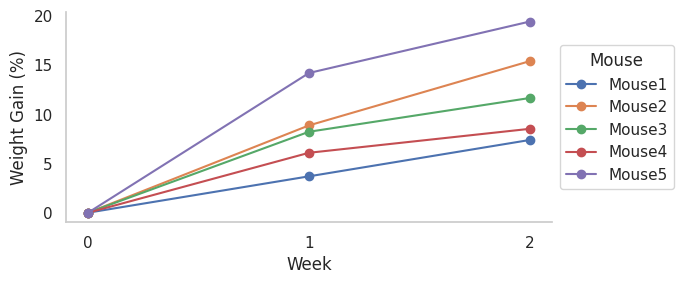

In [ ]:
# @title Plot weights for first 2 weeks of HFD
plt.figure(figsize=(7, 3))
for mouse in weight_data.columns[1:]:
    plt.plot(weight_data["Week"], weight_data[mouse], marker='o', label=mouse)
plt.xlabel("Week")
plt.ylabel("Weight Gain (%)")
plt.xticks([0, 1, 2])
plt.legend(title="Mouse", loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Pearson Correlation Outcomes (α = 0.05)')

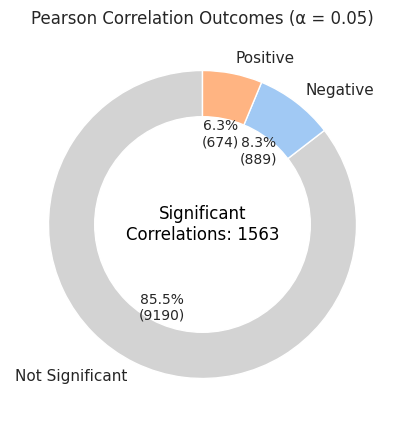

In [185]:
# @title Calculate how many proteins correlate with weight gain over the first 2 weeks
#weight gain in this list:
weights = [2.2, 4.5, 3.3, 2.5, 5.2]
#weights = [7.4, 15.4, 11.6, 8.5, 19.4]

# Proteomic data
data = df.iloc[1:, 4:9].astype(float)
gene_names = df.loc[1:, 'external_gene_name'].astype(str).values

from scipy.stats import t

X = data.to_numpy().copy()
Y = weights - np.mean(weights)
X_centered = X - X.mean(axis=1, keepdims=True)

# Use np.corrcoef for numerical stability
r = np.sum(X_centered * Y, axis=1) / np.sqrt(np.sum(X_centered**2, axis=1) * np.sum(Y**2))
r = np.clip(r, -1, 1)  # numerical safety

n = len(Y)
t_stat = r * np.sqrt((n - 2) / (1 - r**2))
p_values = 2 * (1 - t.cdf(np.abs(t_stat), df=n - 2))

alpha = 0.05
categories = np.where(p_values >= alpha, 'Not Significant',
                      np.where(r > 0, 'Positive', 'Negative'))
counts = pd.Series(categories).value_counts()

# ## 6. Donut Plot
fig, ax = plt.subplots(figsize=(5, 5))
def autopct_with_counts(pct, allvals):
    absolute = int(round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%\n({absolute})"

# Use muted Seaborn color palette
colors = ["#D3D3D3"] + sns.color_palette("pastel", n_colors=len(counts) - 1)

wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    colors=colors,
    autopct=lambda pct: autopct_with_counts(pct, counts),
    startangle=90
)
plt.setp(autotexts, size=10)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add total significant count in center
total_significant = int(counts.get('Positive', 0) + counts.get('Negative', 0))
ax.text(0, 0, f"Significant\nCorrelations: {total_significant}", ha='center', va='center', fontsize=12, color='black')

ax.set_title('Pearson Correlation Outcomes (α = 0.05)')


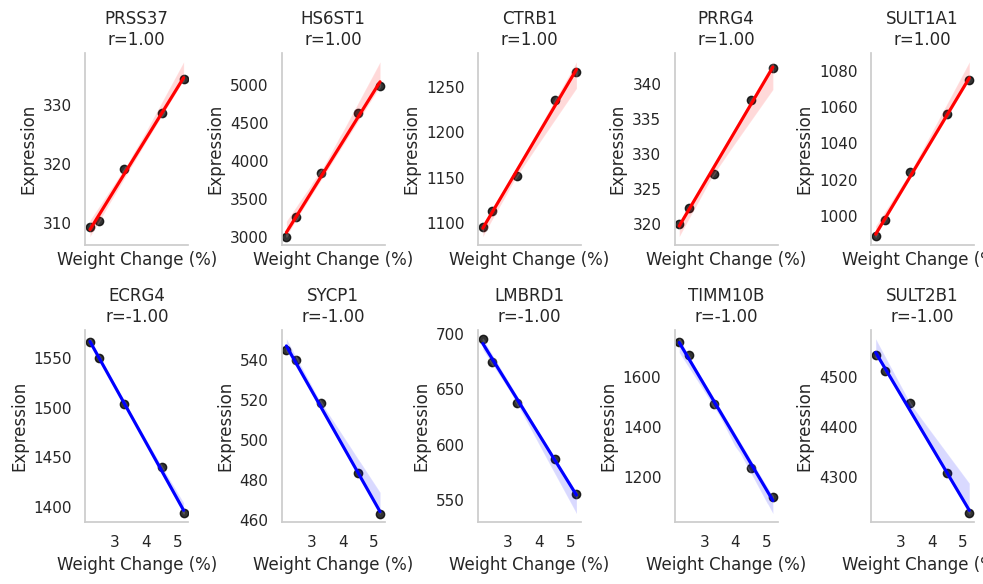

In [186]:
# @title Plot top Positive & Negative Correlations
showtop = 5
sorted_idx = np.argsort(correlations)
top5_neg_idx = sorted_idx[:showtop]
top5_pos_idx = sorted_idx[-showtop:]

fig, axes = plt.subplots(2, showtop, figsize=(10, 6), sharex=True, sharey=False)
axes = axes.flatten()

for i, idx in enumerate(top5_pos_idx):
    ax = axes[i]
    sns.regplot(x=weights, y=data_np[idx], scatter_kws={'color':'black'}, line_kws={'color':'red'}, ax=ax)
    ax.set_title(f"{gene_names[idx]}\nr={correlations[idx]:.2f}", fontsize=12)
    ax.set_xlabel('Weight Change (%)')
    ax.set_ylabel('Expression')
    ax.grid(False)
    sns.despine()

for i, idx in enumerate(top5_neg_idx):
    ax = axes[i+showtop]
    sns.regplot(x=weights, y=data_np[idx], scatter_kws={'color':'black'}, line_kws={'color':'blue'}, ax=ax)
    ax.set_title(f"{gene_names[idx]}\nr={correlations[idx]:.2f}", fontsize=12)
    ax.set_xlabel('Weight Change (%)')
    ax.set_ylabel('Expression')
    ax.grid(False)
    sns.despine()

plt.tight_layout()
plt.show()

Observed significant correlations: 1563
Empirical p-value: 0.0583


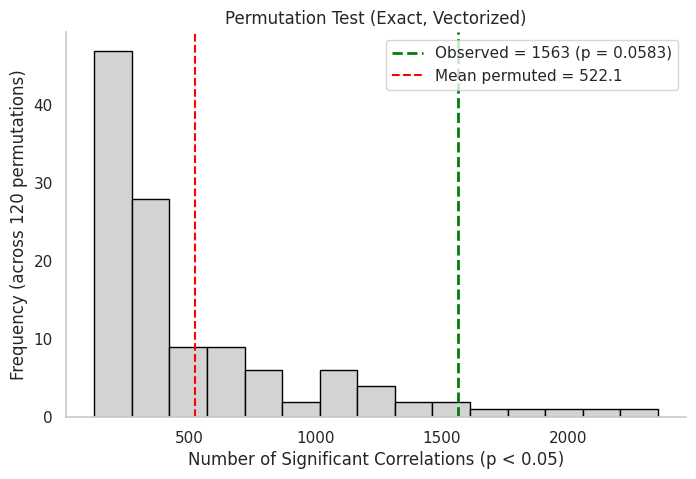

In [187]:
# @title Permuation analysis

import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t

# --- Precompute real correlations ---
data_np = data.to_numpy()
n = len(weights)
alpha = 0.05

x = weights - np.mean(weights)
y = data_np - data_np.mean(axis=1, keepdims=True)
r = np.sum(x * y, axis=1) / np.sqrt(np.sum(x**2) * np.sum(y**2, axis=1))
t_stat = r * np.sqrt((n - 2) / (1 - r**2))
p_values = 2 * (1 - t.cdf(np.abs(t_stat), df=n - 2))
observed_count = np.sum(p_values < alpha)
print(f"Observed significant correlations: {observed_count}")

# --- Exact permutation test (vectorized) ---
all_permutations = np.array(list(itertools.permutations(weights)))
n_permutations = all_permutations.shape[0]
significant_counts = np.zeros(n_permutations, dtype=int)

# Center data for efficiency
y_centered = data_np - data_np.mean(axis=1, keepdims=True)
y_norms = np.sqrt(np.sum(y_centered**2, axis=1))

for i, perm in enumerate(all_permutations):
    x_perm = perm - np.mean(perm)
    # vectorized correlation for all proteins
    r_perm = np.dot(y_centered, x_perm) / (np.sqrt(np.sum(x_perm**2)) * y_norms)
    # vectorized p-values
    t_perm = r_perm * np.sqrt((n - 2) / (1 - r_perm**2))
    p_perm = 2 * (1 - t.cdf(np.abs(t_perm), df=n - 2))
    significant_counts[i] = np.sum(p_perm < alpha)

empirical_p = np.mean(significant_counts >= observed_count)
print(f"Empirical p-value: {empirical_p:.4f}")

# --- Plot histogram ---
plt.figure(figsize=(8, 5))
plt.hist(significant_counts, bins=15, color='lightgray', edgecolor='black')
plt.axvline(observed_count, color='green', linewidth=2, linestyle='--',
            label=f'Observed = {observed_count} (p = {empirical_p:.4f})')
plt.axvline(significant_counts.mean(), color='red', linestyle='--',
            label=f'Mean permuted = {significant_counts.mean():.1f}')
plt.xlabel('Number of Significant Correlations (p < 0.05)')
plt.ylabel('Frequency (across 120 permutations)')
plt.title('Permutation Test (Exact, Vectorized)')
plt.grid(False)
sns.despine()
plt.legend(loc = "upper right");
